In [1275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_blobs

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, AffinityPropagation
from sklearn.mixture import GaussianMixture

from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, rand_score, adjusted_rand_score, normalized_mutual_info_score

In [1208]:
def print_metrics(dataset, labels, y=None):
    print(f"Силуэтный коэффициент: {silhouette_score(dataset, labels)}")
    print(f"Индекс Дэвиса - Болдуина: {davies_bouldin_score(dataset, labels)}")
    print(f"Коэффициент Калински - Карабаса: {calinski_harabasz_score(dataset, labels)}")
    if y is not None:
        print(f"Индекс Rand: {rand_score(y, labels)}")
        print(f"Adjusted Rand Index: {adjusted_rand_score(y, labels)}")
        print(f"Normalized Mutual Information: {normalized_mutual_info_score(y, labels)}")

In [1209]:
def elbow_method(metric, y_label):
    plt.plot(range(2, 15), metric)
    plt.xlabel("K")
    plt.ylabel(y_label)
    plt.show()

# Загрузка и подготовка синтетических данных

In [1210]:
dataset_1 = make_classification(n_samples=2000, n_features=3, n_informative=2, n_redundant=1)
dataset_2 = make_blobs(n_samples=300, n_features=2, centers=5)

X_1, y_1 = dataset_1
X_2, _ = dataset_2

In [ ]:
X_1.describe()

In [1211]:
scaler = StandardScaler()
X_1 = scaler.fit_transform(X_1)
X_2 = scaler.fit_transform(X_2)

# Решение задачи кластеризации на make_blobs

## K-means

In [1212]:
WSS = []
silhouette_scores = []

In [1213]:
for i in range(2, 15):
    km = KMeans(n_clusters=i).fit(X_2)
    WSS.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_2, km.labels_))


### Метод локтя

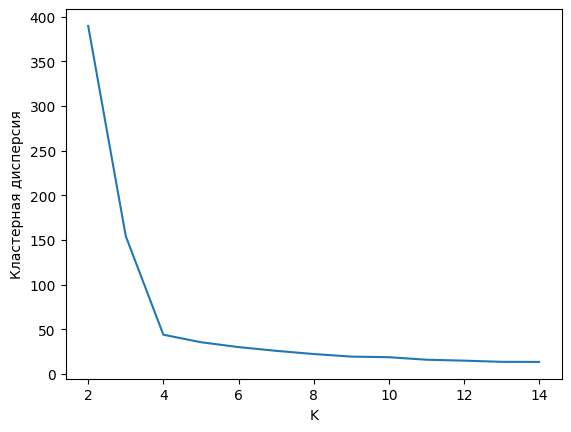

In [1214]:
elbow_method(WSS, y_label='Кластерная дисперсия')

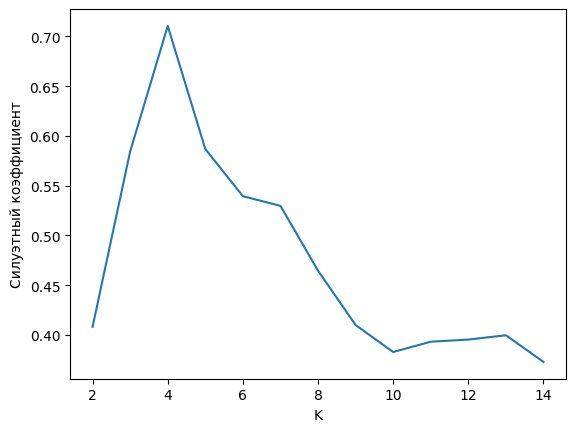

In [1215]:
elbow_method(silhouette_scores, y_label='Силуэтный коэффициент')

In [1216]:
km = KMeans(n_clusters=4).fit(X_2)

In [1217]:
km.labels_

array([1, 0, 1, 3, 3, 1, 2, 1, 2, 1, 0, 3, 2, 2, 3, 1, 1, 0, 3, 1, 0, 1,
       2, 3, 2, 1, 0, 1, 3, 1, 1, 3, 2, 3, 1, 1, 1, 3, 1, 1, 2, 2, 2, 3,
       1, 1, 0, 0, 2, 2, 2, 2, 0, 2, 1, 0, 3, 2, 1, 0, 1, 3, 3, 0, 1, 1,
       1, 0, 0, 0, 3, 3, 3, 1, 1, 3, 1, 1, 0, 1, 1, 3, 2, 0, 0, 3, 1, 0,
       1, 3, 0, 3, 0, 0, 1, 3, 1, 2, 1, 2, 2, 0, 2, 1, 3, 3, 2, 2, 0, 3,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 2, 1, 1, 3, 2, 3, 3, 0, 2, 1, 1, 1, 3,
       2, 0, 3, 1, 1, 3, 0, 0, 2, 1, 1, 2, 1, 2, 0, 1, 0, 1, 1, 3, 0, 3,
       3, 2, 3, 2, 1, 1, 1, 3, 3, 3, 1, 2, 0, 1, 0, 3, 0, 2, 2, 3, 2, 2,
       1, 1, 2, 2, 1, 1, 0, 1, 1, 2, 0, 0, 2, 2, 3, 3, 0, 1, 0, 0, 1, 3,
       1, 2, 0, 1, 2, 1, 1, 1, 1, 3, 2, 0, 2, 3, 0, 3, 3, 1, 1, 3, 2, 1,
       0, 3, 3, 1, 1, 2, 1, 1, 0, 0, 2, 1, 0, 0, 3, 0, 2, 2, 1, 1, 1, 0,
       1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 0, 1, 2, 1, 1, 3, 1, 0, 1, 3, 0, 3,
       1, 1, 3, 0, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 0, 3, 1, 1, 1, 1, 1, 0,
       1, 3, 0, 3, 0, 1, 1, 0, 1, 2, 3, 1, 0, 2], d

In [1218]:
print_metrics(X_2, km.labels_)

Силуэтный коэффициент: 0.7105585733394425
Индекс Дэвиса - Болдуина: 0.3819112158999406
Коэффициент Калински - Карабаса: 1247.2283371523467


## DBSCAN

In [1219]:
dbscan = DBSCAN(min_samples=4).fit(X_2)

In [1220]:
dbscan.labels_

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

Минимальное количество точек в окрестности часто берут как 2 * размерность (в нашем случае - 4)

Далее для каждой точки считают расстояния до k ближайших соседей (k в данном случае равно 4), считая за первого соседа саму точку (иногда не считают саму точку за первого соседа - как захочет исследователь). Полученные значения усредняют

Усредненные значения сортируют по возрастанию и отображают на графике. Знакомая вам локтевая точка (она определяется исследователем по виду графика) может указать на значение эпсилон (это будет координата y)

In [1221]:
nn = NearestNeighbors(n_neighbors=4)
nn.fit(X_2)
distances, indices = nn.kneighbors(X_2)

In [1222]:
mean_distances = np.mean(distances, axis=1)

In [1223]:
mean_distances = np.sort(mean_distances)

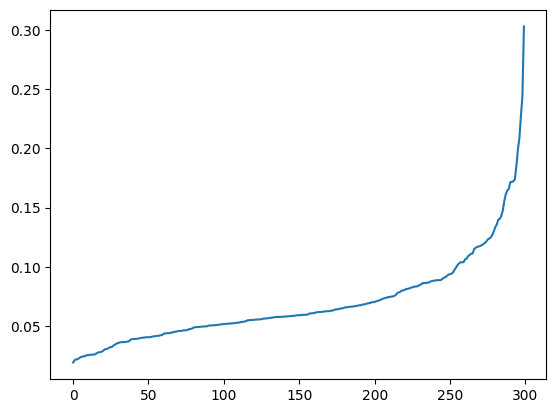

In [1224]:
plt.plot(mean_distances)
plt.show()

In [1225]:
dbscan = DBSCAN(eps=0.15, min_samples=4).fit(X_2)

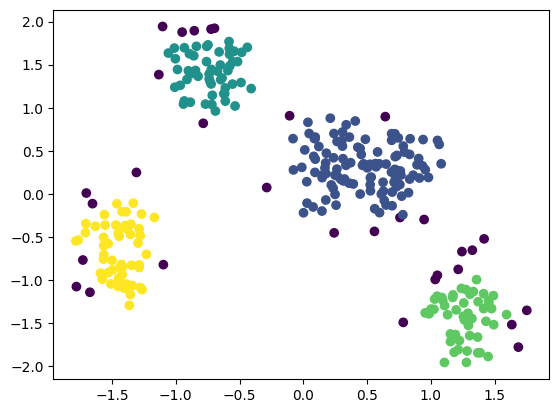

In [1226]:
plt.scatter(X_2[:, 0], X_2[:, 1], c=dbscan.labels_)
plt.show()

In [1227]:
print_metrics(X_2, dbscan.labels_)

Силуэтный коэффициент: 0.591300797726716
Индекс Дэвиса - Болдуина: 1.8530318346008314
Коэффициент Калински - Карабаса: 308.4977109990792


In [1228]:
dbscan = DBSCAN(eps=0.2, min_samples=4).fit(X_2)

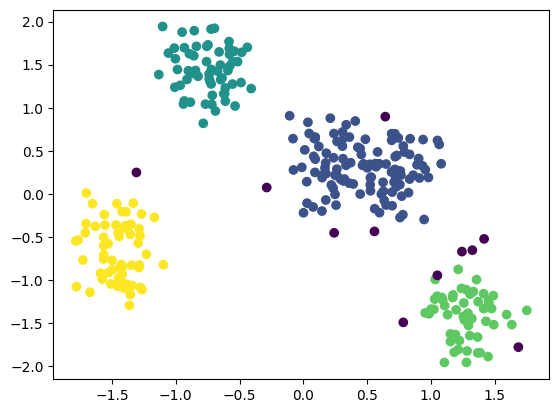

In [1229]:
plt.scatter(X_2[:, 0], X_2[:, 1], c=dbscan.labels_)
plt.show()

In [1230]:
print_metrics(X_2, dbscan.labels_)

Силуэтный коэффициент: 0.6395599646459861
Индекс Дэвиса - Болдуина: 1.0715748097923095
Коэффициент Калински - Карабаса: 784.3062859880391


## HDBSCAN

In [1231]:
hdbscan = HDBSCAN(min_samples=4).fit(X_2)

In [1232]:
hdbscan.labels_

array([2, 3, 2, 0, 0, 2, 1, 2, 1, 2, 3, 0, 1, 1, 0, 2, 2, 3, 0, 2, 3, 2,
       1, 0, 1, 2, 3, 2, 0, 2, 2, 0, 1, 0, 2, 2, 2, 0, 2, 2, 1, 1, 1, 0,
       2, 2, 3, 3, 1, 1, 1, 1, 3, 1, 2, 3, 0, 1, 2, 3, 2, 0, 0, 3, 2, 2,
       2, 3, 3, 3, 0, 0, 0, 2, 2, 0, 2, 2, 3, 2, 2, 0, 1, 3, 3, 0, 2, 3,
       2, 0, 3, 0, 3, 3, 2, 0, 2, 1, 2, 1, 1, 3, 1, 2, 0, 0, 1, 1, 3, 0,
       2, 2, 2, 2, 2, 3, 2, 2, 3, 1, 2, 2, 0, 1, 0, 0, 3, 1, 2, 2, 2, 0,
       1, 3, 0, 2, 2, 0, 3, 3, 1, 2, 2, 1, 2, 1, 3, 2, 3, 2, 2, 0, 3, 0,
       0, 1, 0, 1, 2, 2, 2, 0, 0, 0, 2, 1, 3, 2, 3, 0, 3, 1, 1, 0, 1, 1,
       2, 2, 1, 1, 2, 2, 3, 2, 2, 1, 3, 3, 1, 1, 0, 0, 3, 2, 3, 2, 2, 0,
       2, 1, 3, 2, 1, 2, 2, 2, 2, 0, 1, 3, 1, 0, 3, 0, 0, 2, 2, 0, 1, 2,
       3, 0, 0, 2, 2, 1, 2, 2, 3, 3, 1, 2, 3, 3, 0, 3, 1, 1, 2, 2, 2, 3,
       2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 3, 2, 1, 2, 2, 0, 2, 3, 2, 0, 3, 0,
       2, 2, 0, 3, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 3, 0, 2, 2, 2, 2, 2, 3,
       2, 0, 3, 0, 3, 2, 2, 3, 2, 1, 0, 2, 3, 1])

In [1233]:
print_metrics(X_2, hdbscan.labels_)

Силуэтный коэффициент: 0.7111824229291974
Индекс Дэвиса - Болдуина: 0.38057051470928854
Коэффициент Калински - Карабаса: 1246.125595978165


## GaussianMixture

In [1234]:
loglikelihoods  = []
silhouette_scores = []

In [1235]:
for i in range(2, 15):
    gm = GaussianMixture(n_components=i).fit(X_2)
    loglikelihoods.append(gm.score(X_2))
    silhouette_scores.append(silhouette_score(X_2, gm.predict(X_2)))

### Метод локтя

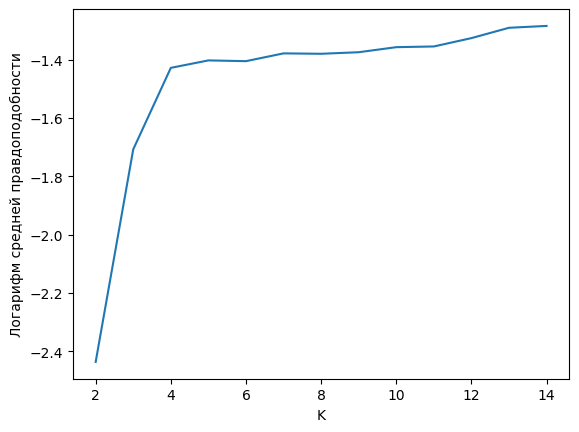

In [1236]:
elbow_method(loglikelihoods, 'Логарифм средней правдоподобности')

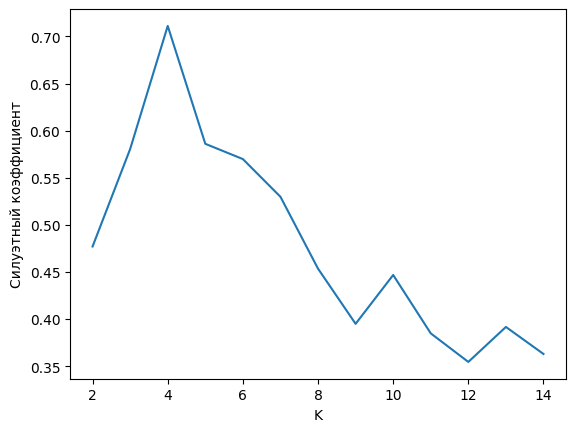

In [1237]:
elbow_method(silhouette_scores, 'Силуэтный коэффициент')

In [1238]:
gm = GaussianMixture(n_components=4).fit(X_2)

In [1239]:
gm.predict(X_2)

array([1, 3, 1, 0, 0, 1, 2, 1, 2, 1, 3, 0, 2, 2, 0, 1, 1, 3, 0, 1, 3, 1,
       2, 0, 2, 1, 3, 1, 0, 1, 1, 0, 2, 0, 1, 1, 1, 0, 1, 1, 2, 2, 2, 0,
       1, 1, 3, 3, 2, 2, 2, 2, 3, 2, 1, 3, 0, 2, 1, 3, 1, 0, 0, 3, 1, 1,
       1, 3, 3, 3, 0, 0, 0, 1, 1, 0, 1, 1, 3, 1, 1, 0, 2, 3, 3, 0, 1, 3,
       1, 0, 3, 0, 3, 3, 1, 0, 1, 2, 1, 2, 2, 3, 2, 1, 0, 0, 2, 2, 3, 0,
       1, 1, 1, 1, 1, 3, 1, 1, 3, 2, 1, 1, 0, 2, 0, 0, 3, 2, 1, 1, 1, 0,
       2, 3, 0, 1, 1, 0, 3, 3, 2, 1, 1, 2, 1, 2, 3, 1, 3, 1, 1, 0, 3, 0,
       0, 2, 0, 2, 1, 1, 1, 0, 0, 0, 1, 2, 3, 1, 3, 0, 3, 2, 2, 0, 2, 2,
       1, 1, 2, 2, 1, 1, 3, 1, 1, 2, 3, 3, 2, 2, 0, 0, 3, 1, 3, 1, 1, 0,
       1, 2, 3, 1, 2, 1, 1, 1, 1, 0, 2, 3, 2, 0, 3, 0, 0, 1, 1, 0, 2, 1,
       3, 0, 0, 1, 1, 2, 1, 1, 3, 3, 2, 1, 3, 3, 0, 3, 2, 2, 1, 1, 1, 3,
       1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 3, 1, 2, 1, 1, 0, 1, 3, 1, 0, 3, 0,
       1, 1, 0, 3, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 3, 0, 1, 1, 1, 1, 1, 3,
       1, 0, 3, 0, 3, 1, 1, 3, 1, 2, 0, 1, 3, 2])

In [1240]:
print_metrics(X_2, gm.predict(X_2))

Силуэтный коэффициент: 0.7111824229291974
Индекс Дэвиса - Болдуина: 0.38057051470928854
Коэффициент Калински - Карабаса: 1246.125595978165


## AffinityPropagation

In [1241]:
dampings = [0.5, 0.6, 0.7, 0.8, 0.9]
preferences = [-50, -15, -5]

In [1242]:
best_solution = -1
answer = ''

for damping in dampings:
    for preference in preferences:
        af = AffinityPropagation(damping=damping, preference=preference).fit(X_2)
        unique_labels = np.unique(af.labels_)
        if len(unique_labels) < 2:
            continue
        if silhouette_score(X_2, af.labels_) > best_solution:
            best_solution = silhouette_score(X_2, af.labels_)
            answer  = f"preference = {preference}, damping = {damping}"
print(answer)
print(best_solution)

/Users/macbook/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


preference = -50, damping = 0.7
0.7111824229291974


In [1243]:
af = AffinityPropagation(damping=0.5, preference=-15).fit(X_2)
print_metrics(X_2, af.labels_)

Силуэтный коэффициент: 0.4295677736040282
Индекс Дэвиса - Болдуина: 0.35252988708095434
Коэффициент Калински - Карабаса: 90.89576464983851


/Users/macbook/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


# Решение задачи кластеризации на make_classification

## K-means

In [1244]:
WSS = []
silhouette_scores = []

In [1245]:
for i in range(2, 15):
    km = KMeans(n_clusters=i).fit(X_1)
    WSS.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_1, km.labels_))


### Метод локтя

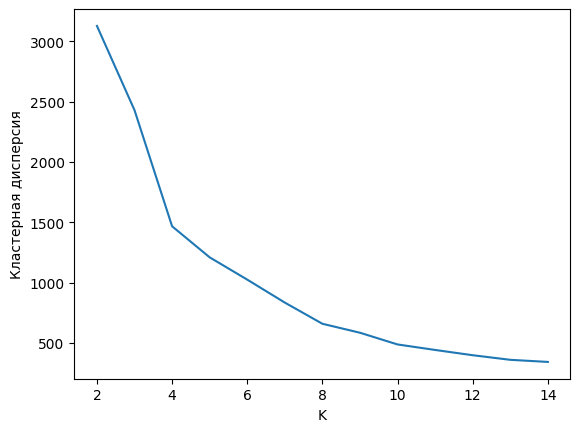

In [1246]:
elbow_method(WSS, y_label='Кластерная дисперсия')

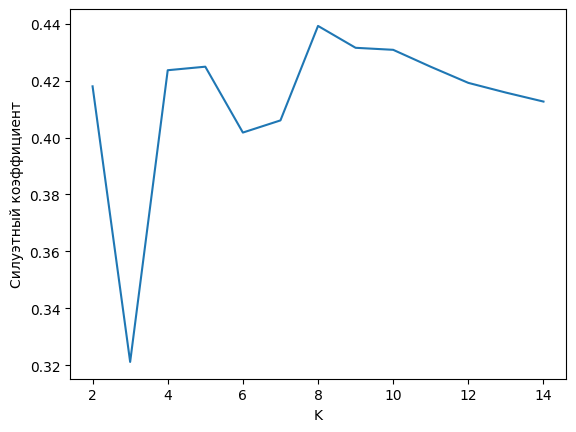

In [1247]:
elbow_method(silhouette_scores, y_label='Силуэтный коэффициент')

In [1248]:
km = KMeans(n_clusters=4).fit(X_1)

In [1249]:
km.labels_

array([2, 3, 0, ..., 1, 1, 3], dtype=int32)

In [1250]:
print_metrics(X_1, km.labels_, y_1)

Силуэтный коэффициент: 0.42334140129844083
Индекс Дэвиса - Болдуина: 0.8039357791081937
Коэффициент Калински - Карабаса: 2056.1065351923726
Индекс Rand: 0.6450520260130065
Adjusted Rand Index: 0.2899338858374147
Normalized Mutual Information: 0.38129110784840575


## DBSCAN

In [1251]:
dbscan = DBSCAN(min_samples=4).fit(X_1)

In [1252]:
dbscan.labels_

array([0, 0, 0, ..., 0, 0, 0])

Минимальное количество точек в окрестности часто берут как 2 * размерность (в нашем случае - 6)

Далее для каждой точки считают расстояния до k ближайших соседей (k в данном случае равно 4), считая за первого соседа саму точку (иногда не считают саму точку за первого соседа - как захочет исследователь). Полученные значения усредняют

Усредненные значения сортируют по возрастанию и отображают на графике. Знакомая вам локтевая точка (она определяется исследователем по виду графика) может указать на значение эпсилон (это будет координата y)

In [1253]:
nn = NearestNeighbors(n_neighbors=6)
nn.fit(X_1)
distances, indices = nn.kneighbors(X_1)

In [1254]:
mean_distances = np.mean(distances, axis=1)

In [1255]:
mean_distances = np.sort(mean_distances)

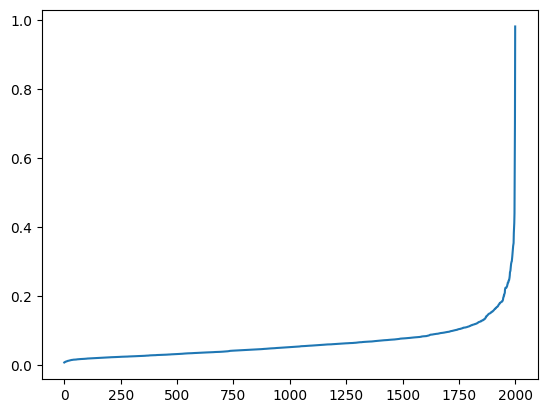

In [1256]:
plt.plot(mean_distances)
plt.show()

In [1257]:
dbscan = DBSCAN(eps=0.15, min_samples=6).fit(X_1)

In [1258]:
print_metrics(X_1, dbscan.labels_)

Силуэтный коэффициент: -0.2251269173666824
Индекс Дэвиса - Болдуина: 2.5656773832364705
Коэффициент Калински - Карабаса: 31.69240948150501


In [1259]:
dbscan = DBSCAN(eps=0.2, min_samples=4).fit(X_1)

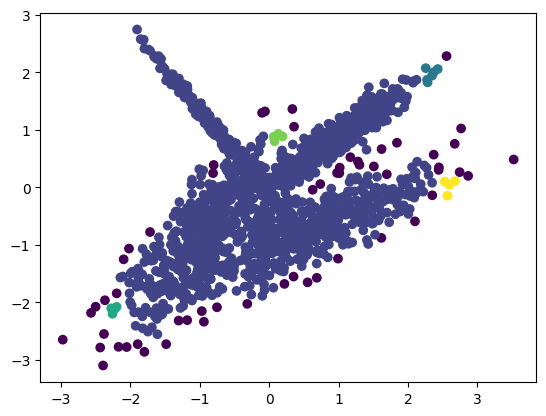

In [1260]:
plt.scatter(X_1[:, 0], X_1[:, 1], c=dbscan.labels_)
plt.show()

In [1261]:
print_metrics(X_1, dbscan.labels_)

Силуэтный коэффициент: -0.2962403148253915
Индекс Дэвиса - Болдуина: 2.3575692271038533
Коэффициент Калински - Карабаса: 16.94641377601587


## HDBSCAN

In [1262]:
hdbscan = HDBSCAN(min_samples=6).fit(X_1)

In [1263]:
hdbscan.labels_

array([-1, -1, -1, ..., -1, -1, -1])

In [1264]:
print_metrics(X_1, hdbscan.labels_)

Силуэтный коэффициент: -0.18522466629211662
Индекс Дэвиса - Болдуина: 2.161876266316432
Коэффициент Калински - Карабаса: 33.16180425086243


## GaussianMixture

In [1265]:
loglikelihoods  = []
silhouette_scores = []

In [1266]:
for i in range(2, 15):
    gm = GaussianMixture(n_components=i).fit(X_1)
    loglikelihoods.append(gm.score(X_1))
    silhouette_scores.append(silhouette_score(X_1, gm.predict(X_1)))

### Метод локтя

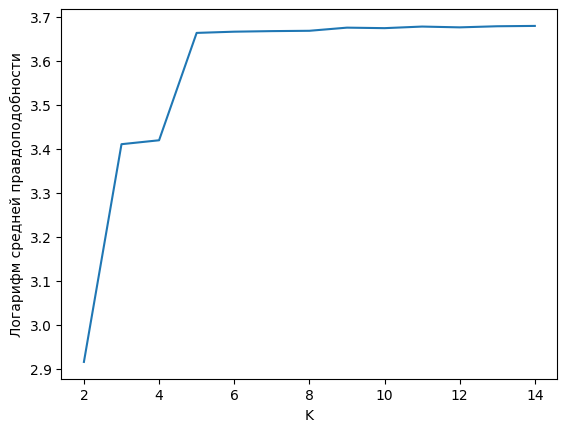

In [1267]:
elbow_method(loglikelihoods, 'Логарифм средней правдоподобности')

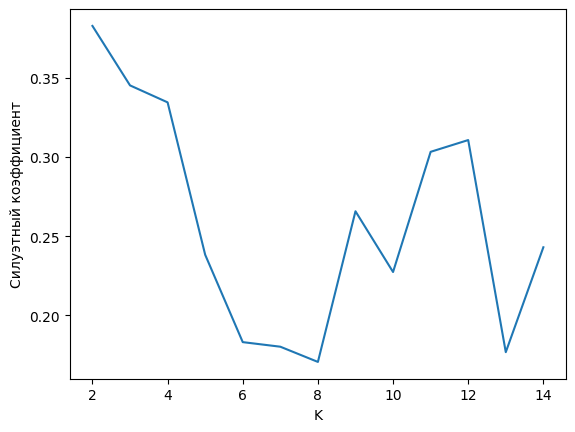

In [1268]:
elbow_method(silhouette_scores, 'Силуэтный коэффициент')

In [1269]:
gm = GaussianMixture(n_components=6).fit(X_1)

In [1270]:
gm.predict(X_1)

array([0, 2, 2, ..., 3, 3, 3])

In [1271]:
print_metrics(X_1, gm.predict(X_1))

Силуэтный коэффициент: 0.23913448694325842
Индекс Дэвиса - Болдуина: 1.2410571042925056
Коэффициент Калински - Карабаса: 1208.395216645792


## AffinityPropagation

In [1272]:
dampings = [0.5, 0.6, 0.7, 0.8, 0.9]
preferences = [-50, -15, -5]

In [1273]:
best_solution = -1
answer = ''

for damping in dampings:
    for preference in preferences:
        af = AffinityPropagation(damping=damping, preference=preference).fit(X_1)
        unique_labels = np.unique(af.labels_)
        if len(unique_labels) < 2:
            continue
        if silhouette_score(X_1, af.labels_) > best_solution:
            best_solution = silhouette_score(X_1, af.labels_)
            answer  = f"preference = {preference}, damping = {damping}"
print(answer)
print(best_solution)

/Users/macbook/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
/Users/macbook/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
/Users/macbook/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
/Users/macbook/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
/Users/macbook/Library/Python/3.

preference = -50, damping = 0.9
0.4276568689146668


In [1274]:
af = AffinityPropagation(damping=0.9, preference=-50).fit(X_1)
print_metrics(X_1, af.labels_)

Силуэтный коэффициент: 0.4276568689146668
Индекс Дэвиса - Болдуина: 0.7214945057179102
Коэффициент Калински - Карабаса: 2499.3870432247927


## Реализация K-means

In [ ]:
import numpy as np
import pandas as pd

def k_means(data, n_clusters, n_iter):

    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    
    centroids = []
    for _ in range(n_clusters):
        centroid = []
        for column in data.columns:
            min_value = data[column].min()
            max_value = data[column].max()
            centroid.append(np.random.uniform(min_value, max_value))
        centroids.append(centroid)
    centroids = np.array(centroids)
    
    for _ in range(n_iter):
        labels = np.zeros(data.shape[0])
        
        for j in range(data.shape[0]):
            min_dist = np.inf
            label = 0
            
            for i in range(n_clusters):
                dist = np.sum((data.values[j] - centroids[i])**2)
                if dist < min_dist:
                    min_dist = dist
                    label = i
            labels[j] = label
        
        new_centroids = []
        for i in range(n_clusters):
            cluster_points = data.values[labels == i]
            if len(cluster_points) > 0:
                new_centroids.append(cluster_points.mean(axis=0))
            else:
                new_centroids.append(centroids[i])
        
        centroids = np.array(new_centroids)
    
    return labels, centroids

In [1348]:
labels, centroids = k_means(X_2, 3, 20)

In [1349]:
print_metrics(X_2, labels)

Силуэтный коэффициент: 0.5425152352048482
Индекс Дэвиса - Болдуина: 0.7962212939068084
Коэффициент Калински - Карабаса: 323.84928521322126


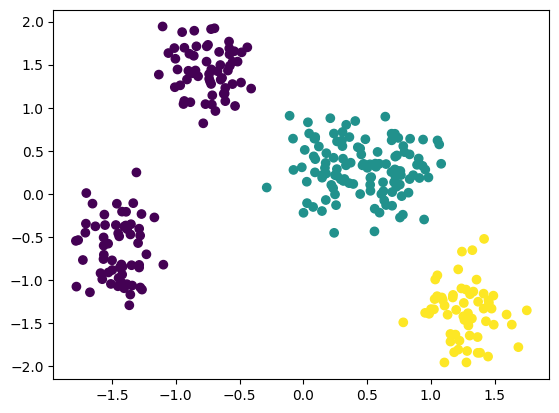

In [1350]:
plt.scatter(X_2[:, 0], X_2[:, 1], c=labels)
plt.show()